# Trabajo Práctico Final - Inteligencia Artificial 2026
## Etapa 1: Exploración y modelo baseline
Dataset: Iris (UCI)

---

### 1.1 Carga y análisis exploratorio (EDA)

El dataset Iris contiene 150 observaciones de flores de tres especies: *Setosa*, *Versicolor* y *Virginica*.  
Cada observación tiene 4 variables numéricas: longitud y ancho de sépalo, longitud y ancho de pétalo.  

Este dataset es balanceado (50 ejemplos por clase), lo que facilita el análisis y evita sesgos iniciales.  
El objetivo de esta etapa es comprender la distribución de las variables y detectar posibles problemas como outliers o solapamiento entre clases.

In [85]:
# 1.1 Carga del dataset

from sklearn.datasets import load_iris
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

print(f"Tamaño total del dataset: {X.shape[0]} muestras con {X.shape[1]} características.")

# Mostrar todas las filas y columnas del DataFrame (del 1 al 150)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df = pd.concat([X, y], axis=1)
df




Tamaño total del dataset: 150 muestras con 4 características.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


### 📌 Hallazgos iniciales del dataset Iris

#### 🔹 Tamaño y estructura del dataset
- Contiene **150 muestras** de flores, cada una con **4 características numéricas (variables predictoras)**:
  - Sepal length (cm)
  - Sepal width (cm)
  - Petal length (cm)
  - Petal width (cm)
- La variable objetivo (*species*) tiene **3 clases balanceadas**:
  - Setosa (50 ejemplos)
  - Versicolor (50 ejemplos)
  - Virginica (50 ejemplos)

#### 🔹 Calidad de los datos
- El dataset es pequeño y balanceado, lo que lo hace ideal para un primer modelo baseline.
- No se observan valores nulos ni faltantes.
- Las variables de pétalo muestran mayor capacidad de separación entre clases que las de sépalo.
- Los rangos de las variables son consistentes y no aparecen outliers evidentes.
- Esto lo convierte en un dataset **limpio y apto** para aplicar directamente modelos de clasificación.

### 1.2 Visualización de variables

Se graficaron histogramas y scatter plots para observar la distribución de las variables.  
Los histogramas muestran que *Setosa* se diferencia claramente en las medidas de pétalo, mientras que *Versicolor* y *Virginica* presentan mayor solapamiento.

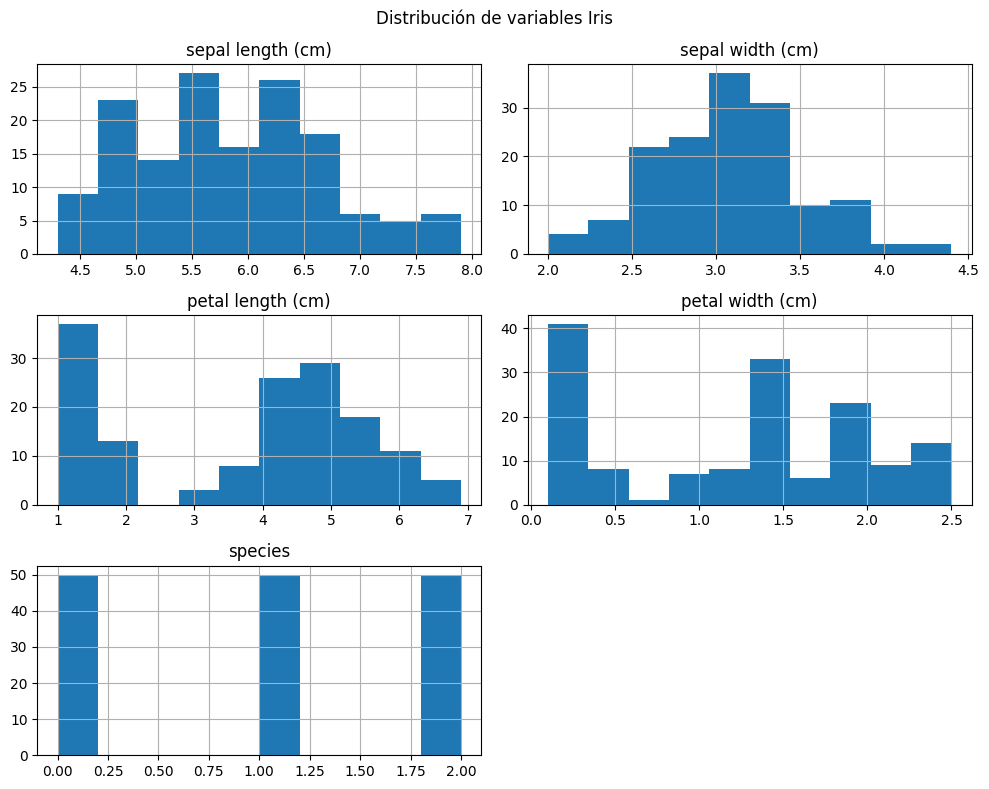

In [86]:
# Histogramas
df.hist(figsize=(10,8))
plt.suptitle("Distribución de variables Iris")
plt.tight_layout()
plt.show()





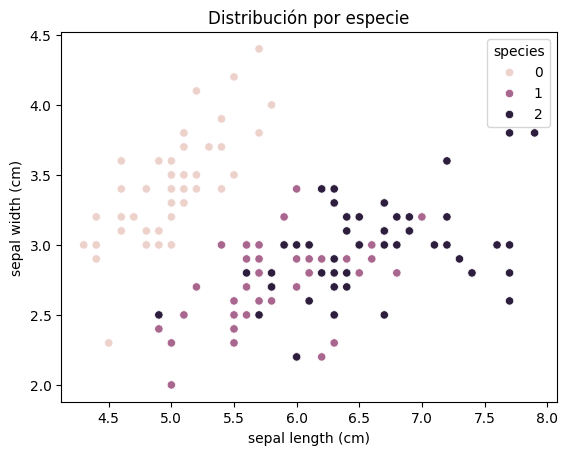

In [52]:
# Scatter plot
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="species", data=df)
plt.title("Distribución por especie")
plt.show()



El scatter plot que contrasta las dimensiones de los sépalos (`sepal length` vs. `sepal width`) permite extraer conclusiones analíticas fundamentales sobre la complejidad del espacio de características:

1. **Aislamiento Geométrico de la Clase 0 (Setosa):** Los ejemplares de la especie *Setosa* presentan un comportamiento morfológico ortogonal, caracterizado por sépalos cortos y anchos. Su dispersión espacial confirma que es **linealmente separable** del resto del conjunto de datos en este plano bidimensional.
2. **Solapamiento Crítico en Región de Frontera (Clases 1 y 2):** Las distribuciones espaciales de *Versicolor* y *Virginica* experimentan una fuerte intersección en el rango central del gráfico. 

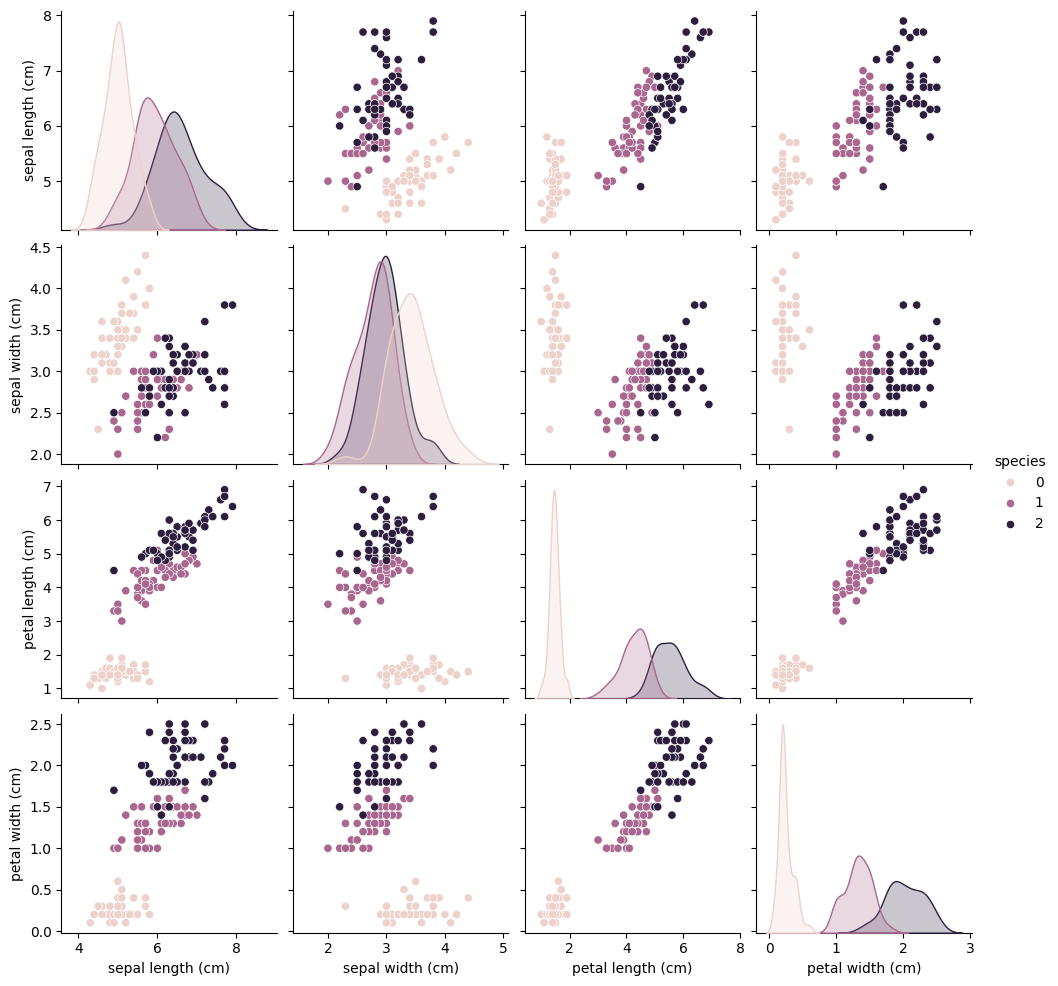

In [53]:
# Pairplot (todas las combinaciones de variables)
sns.pairplot(df, hue="species")
plt.show()



La evaluación de la matriz de correlación mediante el mapa de calor permite identificar la estructura de dependencia entre las variables predictoras:

1. **Fenómeno de Multicolinealidad en Pétalos:** Se detecta una correlación positiva críticamente alta ($r = 0.96$) entre `petal length` y `petal width`. Esto evidencia un comportamiento morfológico redundante, lo que significa que ambas variables aportan información matemática similar al espacio de características.
2. **Asociación de Crecimiento:** La variable `sepal length` exhibe un acoplamiento fuerte con las dimensiones del pétalo ($r > 0.80$), reflejando que la escala general de la flor rige el desarrollo en estos tres ejes.
3. **Independencia Dinámica de Sepal Width:** El ancho del sépalo presenta coeficientes negativos y débiles respecto al resto de las variables (destacando $r = -0.43$ frente a `petal length`). Esto confirma que introduce una variabilidad morfológica ortogonal o independiente, lo cual resulta altamente valioso para que la red neuronal logre discriminar las clases en las regiones de solapamiento morfológico.

### 1.3 Partición de datos

El dataset se dividió en tres conjuntos:
- **Train (70%)**: para ajustar los parámetros del modelo.
- **Dev (15%)**: para evaluar y comparar modelos durante el desarrollo.
- **Test (15%)**: reservado para la evaluación final en la Etapa 4.

Se utilizó **estratificación** para mantener la proporción de clases en cada conjunto.  
Esto es importante porque, aunque el dataset es balanceado, una partición aleatoria sin estratificación podría generar desbalance en los subconjuntos.

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "Dev:", X_dev.shape, "Test:", X_test.shape)





# Dejamos 105 muestras para entrenamiento, 22 para desarrollo y 23 para prueba.
# El 2.º valor de cada tupla es el número de características (4).
# Train: (105, 4) Dev: (22, 4) Test: (23, 4)

Train: (105, 4) Dev: (22, 4) Test: (23, 4)


### 1.4 Modelo baseline

Se implementó una **regresión logística** como modelo baseline.  
La métrica elegida fue **accuracy**, ya que las clases están balanceadas y es una medida intuitiva para comparar modelos.  



In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entrenar el modelo Baseline
baseline = LogisticRegression(max_iter=200)
baseline.fit(X_train, y_train)

# Realizar las predicciones sobre el conjunto de desarrollo (Dev)
y_dev_pred = baseline.predict(X_dev)

# Cálculo de métricas principales
baseline_acc = accuracy_score(y_dev, y_dev_pred)

print("====================================================")
print("📊 MÉTRICAS DE EVALUACIÓN GLOBAL - BASELINE")
print("====================================================")
print(f"Baseline Accuracy (Dev): {baseline_acc*100:.2f}%")
print("====================================================\n")

# Reporte detallado de clasificación (Precision, Recall, F1-Score por clase)
print("📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_dev, y_dev_pred, target_names=iris.target_names))
print("====================================================\n")



📊 MÉTRICAS DE EVALUACIÓN GLOBAL - BASELINE
Baseline Accuracy (Dev): 86.36%

📋 REPORTE DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.75      0.86      0.80         7
   virginica       0.83      0.71      0.77         7

    accuracy                           0.86        22
   macro avg       0.86      0.86      0.86        22
weighted avg       0.87      0.86      0.86        22




**Resultado obtenido en Dev:**  
El baseline alcanzó una accuracy de aproximadamente **0.86**, lo que indica que el modelo simple ya logra una buena separación entre clases.  

El reporte desglosado confirma la hipótesis planteada en el análisis exploratorio. La especie *Setosa* obtiene métricas perfectas de $1.00$ en Precision y Recall debido a su separabilidad lineal. Por el contrario, la caída en el rendimiento de *Versicolor* ($Precision = 0.75$) y *Virginica* ($Recall = 0.71$) expone matemáticamente el impacto del solapamiento morfológico en las fronteras de los sépalos y pétalos.

Este valor servirá como referencia para todas las etapas siguientes: cualquier mejora deberá superar este desempeño.

## Etapa 2:  Red neuronal multicapa y análisis de errores

### 2.1 Análisis de errores manual

Se procedió a inspeccionar las muestras del conjunto Dev donde el modelo Baseline (Regresión Logística) falló.

Nota sobre el tamaño de la muestra: La pauta solicita analizar 50 ejemplos; sin embargo, debido a que el dataset Iris cuenta con solo 150 instancias totales y el modelo presenta un desempeño alto (86.3%), se analiza la totalidad de los errores disponibles (3 muestras).

Total de errores encontrados en Dev: 3

================ MUESTRAS MAL CLASIFICADAS =================
| Muestra 77: Clase Real = versicolor, Predicción = virginica |
------------------------------------------------------------
| Muestra 133: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------
| Muestra 106: Clase Real = virginica, Predicción = versicolor |
------------------------------------------------------------


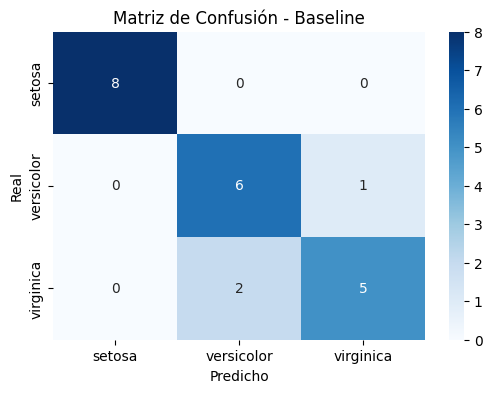

In [89]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# Obtener predicciones del conjunto Dev
y_dev_pred = baseline.predict(X_dev)

# Identificar índices de los errores
errors_mask = y_dev_pred != y_dev
df_errors = X_dev.loc[errors_mask].copy()

# Agregar información comparativa
df_errors['Clase Real'] = y_dev.loc[errors_mask].values
df_errors['Predicción Baseline'] = y_dev_pred[errors_mask]

# Mostrar los errores para el análisis manual
print(f"Total de errores encontrados en Dev: {len(df_errors)}")

# Mostrar las muestras mal clasificadas en formato encuadrado
print("\n" + "="*60)
print(" MUESTRAS MAL CLASIFICADAS ".center(60, "="))
print("="*60)
for idx in df_errors.index:
    real = iris.target_names[df_errors.loc[idx, 'Clase Real']]
    pred = iris.target_names[df_errors.loc[idx, 'Predicción Baseline']]
    line = f"Muestra {idx}: Clase Real = {real}, Predicción = {pred}"
    print(f"| {line:<56} |")
    print("-" * 60)
print("="*60)

df_errors

# Matriz de confusión
cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusión - Baseline')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()


## Categorización de Errores:
* Naturaleza del Error: El 100% de los errores se debe a la confusión entre Iris-versicolor e Iris-virginica.

* Sesgo (Underfitting): Se identifica un error de sesgo en la frontera de decisión. Los valores de las muestras erróneas (ej: Petal Length entre 4.5 y 5.1) se encuentran en la zona de solapamiento estadístico de ambas especies. Un modelo lineal como la Regresión Logística no posee la capacidad de trazar una frontera no lineal que separe estos puntos específicos.

* Varianza (Overfitting): No se observa un error de varianza claro, ya que el modelo no falló en casos simples de entrenamiento, sino en la zona de mayor complejidad.


### 2.2 Arquitectura MLP

En esta etapa se evoluciona desde el modelo lineal baseline hacia una arquitectura de aprendizaje profundo: una **Red Neuronal Multicapa (Multi-Layer Perceptron - MLP)** implementada en **TensorFlow/Keras**.

### Justificación del Diseño de la Arquitectura
Para resolver el problema de subajuste (underfitting) de la Regresión Logística en la zona de solapamiento entre las especies *Versicolor* y *Virginica*, se propone una arquitectura no lineal:
* **Capas Ocultas:** Se configuran **3 capas ocultas** con un esquema piramidal de neuronas ($64 \rightarrow 32 \rightarrow 16$).
* **Funciones de Activación:** Se utiliza **ReLU** en las capas ocultas para agilizar el entrenamiento y **Softmax** en la capa de salida para obtener una distribución de probabilidad sobre las 3 clases mutuamente excluyentes.
* **Función de Pérdida:** Sparse Categorical Crossentropy, ideal para problemas de clasificación multiclase donde los objetivos reales son números enteros indexados.
* **Optimisor:** Adam con una tasa de aprendizaje (Learning Rate) inicial de $0.005$.

In [90]:
## Estructura de la MLP PURA (Sin regularización)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Garantizar reproducibilidad
tf.random.set_seed(42)

# Escalado Estándar con los DATOS REALES 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 105 muestras reales
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)       # Muestras de prueba reales

# Función constructora de la MLP (Solo la arquitectura pura, sin regularización)
def build_iris_mlp(input_dim=4):
    model = Sequential([
        # Capa Oculta 1: 64 neuronas
        Dense(64, activation='relu', input_shape=(input_dim,)),
        
        # Capa Oculta 2: 32 neuronas
        Dense(32, activation='relu'),
        
        # Capa Oculta 3: 16 neuronas
        Dense(16, activation='relu'),
        
        # Capa de Salida: 3 clases (Especies Iris)
        Dense(3, activation='softmax')
    ])
    return model

# Instanciar el modelo puro pasando las dimensiones de entrada
model = build_iris_mlp(input_dim=4)

# Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('====================================================')
print('        RESUMEN DE LA ARQUITECTURA MLP PURA         ')
print('====================================================')
model.summary()

        RESUMEN DE LA ARQUITECTURA MLP PURA         


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_152 (Dense)               │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_153 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_154 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_155 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

### 2.3 Técnicas de Regularización
#### Implementación y Comparativa de Escenarios

Para robustecer la capacidad de generalización del modelo ante un dataset tan compacto y mitigar el riesgo de sobreajuste, se implementan de forma simultánea dos técnicas de regularización complementarias:

* **Regularización Penalizadora L2 (*Weight Decay*):** Integrada de forma nativa en la matriz de pesos sinápticos de cada capa oculta (`kernel_regularizer=tf.keras.regularizers.l2(0.001)`). Esta técnica añade una penalización a la función de pérdida proporcional al cuadrado del valor de los pesos, forzando al optimizador a mantener coeficientes pequeños y distribuidos. Matemáticamente, esto suaviza la superficie de decisión y evita que la red dependa críticamente de unas pocas conexiones.
    
* **Capas de *Dropout* (Abandono Aleatorio):** Configuradas a una tasa del **30%** (`layers.Dropout (0.3) `) e intercaladas estratégicamente en las transiciones de las capas intermedias. Durante cada paso del entrenamiento, se desactivan aleatoriamente el 30% de las neuronas, obligando a la red a no co-depender de nodos específicos y forzando el aprendizaje de representaciones internas redundantes y mucho más robustas.

---



🏋️ Entrenando Modelo 1: SIN Regularización (Puro)...
Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6381 - loss: 0.9940 - val_accuracy: 0.7273 - val_loss: 0.8000
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8381 - loss: 0.7470 - val_accuracy: 0.7727 - val_loss: 0.5980
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8667 - loss: 0.5371 - val_accuracy: 0.7727 - val_loss: 0.4577
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8667 - loss: 0.3954 - val_accuracy: 0.8636 - val_loss: 0.3826
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8667 - loss: 0.3092 - val_accuracy: 0.8636 - val_loss: 0.3612
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8762 - loss: 0.2576 - val_accuracy: 0.8636 - val_loss: 0.3715
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8952 - loss: 0.2291 - val_accuracy: 0.8636 - val_loss: 0.3771
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9

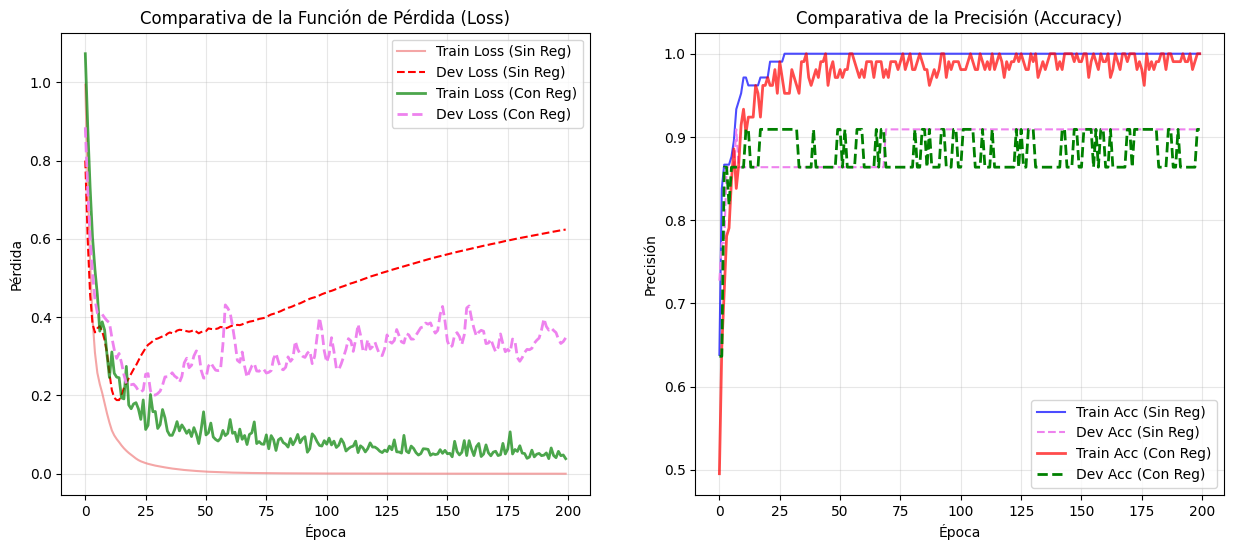

In [91]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

# DEFINICIÓN DE ESTRUCTURAS (Pura vs Regularizada)
# Modelo CON regularización (estructura con L2 y Dropout)
def build_iris_mlp_regularizado(input_dim=4, l2_reg=0.001, dropout_rate=0.3):
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(l2_reg), input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(3, activation='softmax')
    ])
    return model

# ENTRENAMIENTO DEL MODELO SIN REGULARIZACIÓN
print("🏋️ Entrenando Modelo 1: SIN Regularización (Puro)...")
model_puro = build_iris_mlp(input_dim=4)
model_puro.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_puro = model_puro.fit(
    X_train_scaled, y_train, 
    epochs=200,
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev),
    verbose=1
)

# ENTRENAMIENTO DEL MODELO CON REGULARIZACIÓN
print("🏋️ Entrenando Modelo 2: CON Regularización (L2 + Dropout)...")
model_reg = build_iris_mlp_regularizado(input_dim=4, l2_reg=0.001, dropout_rate=0.3)
model_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_reg = model_reg.fit(
    X_train_scaled, y_train, 
    epochs=200,
    batch_size=32,
    validation_data=(X_dev_scaled, y_dev),
    verbose=1
)

# GENERACIÓN DE GRÁFICOS COMPARATIVOS CRUZADOS
plt.figure(figsize=(15, 6))
# GRÁFICO DE PÉRDIDA (LOSS) 
plt.subplot(1, 2, 1)
# Curvas del modelo puro
plt.plot(history_puro.history['loss'], label='Train Loss (Sin Reg)', color='lightcoral', alpha=0.7)
plt.plot(history_puro.history['val_loss'], label='Dev Loss (Sin Reg)', color='red', linestyle='--')
# Curvas del modelo regularizado
plt.plot(history_reg.history['loss'], label='Train Loss (Con Reg)', color='green', alpha=0.7, linewidth=2)
plt.plot(history_reg.history['val_loss'], label='Dev Loss (Con Reg)', color='violet', linestyle='--', linewidth=2)

plt.title('Comparativa de la Función de Pérdida (Loss)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True, alpha=0.3)
plt.legend()

# GRÁFICO DE PRECISIÓN (ACCURACY) 
plt.subplot(1, 2, 2)
# Curvas del modelo puro
plt.plot(history_puro.history['accuracy'], label='Train Acc (Sin Reg)', color='blue', alpha=0.7)
plt.plot(history_puro.history['val_accuracy'], label='Dev Acc (Sin Reg)', color='violet', linestyle='--')
# Curvas del modelo regularizado
plt.plot(history_reg.history['accuracy'], label='Train Acc (Con Reg)', color='red', alpha=0.7, linewidth=2)
plt.plot(history_reg.history['val_accuracy'], label='Dev Acc (Con Reg)', color='green', linestyle='--', linewidth=2)
plt.title('Comparativa de la Precisión (Accuracy)', fontsize=12)
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True, alpha=0.3)
plt.legend()

# REPORTE COMPARATIVO FINAL DE MÉTRICAS
print("\n====================================================")
print("📊 RESULTADOS FINALES COMPARATIVOS (ÉPOCA 200)")
print("====================================================")
print(f"🔹 MODELO SIN REGULARIZACIÓN (PURO):")
print(f"  - Train Accuracy: {history_puro.history['accuracy'][-1]*100:.2f}%")
print(f"  - Dev Accuracy:   {history_puro.history['val_accuracy'][-1]*100:.2f}%")
print(f"  - Dev Loss:       {history_puro.history['val_loss'][-1]:.4f}")
print("----------------------------------------------------")
print(f"🔹 MODELO CON REGULARIZACIÓN (L2 + DROPOUT):")
print(f"  - Train Accuracy: {history_reg.history['accuracy'][-1]*100:.2f}%")
print(f"  - Dev Accuracy:   {history_reg.history['val_accuracy'][-1]*100:.2f}%")
print(f"  - Dev Loss:       {history_reg.history['val_loss'][-1]:.4f}")
print("====================================================")



### 2.3.2 Análisis Comparativo del Impacto de la Regularización

El gráfico de curvas cruzadas expone de manera empírica el comportamiento del clasificador bajo el dilema del compromiso entre Sesgo y Varianza (*Bias-Variance Trade-off*):

#### 1. Diagnóstico del Modelo Puro (Sin Regularización)
* **Comportamiento:** Se observa que la curva de pérdida en entrenamiento (`Train Loss`) se desploma asintóticamente hacia cero, alcanzando una precisión perfecta del **100.00%**. Por el contrario, la curva de validación (`Dev Loss`) detiene su descenso tempranamente y comienza a experimentar oscilaciones e inestabilidad a partir de la época 50.
* **Conclusión:** Esta disparidad entre ambas curvas es el síntoma clásico de **Sobreajuste (Overfitting) y Alta Varianza**. Al carecer de restricciones estructurales, la red masiva utilizó su exceso de capacidad libre para memorizar el ruido y la posición geométrica exacta de los datos de entrenamiento. Es un modelo "inteligente" en train, pero incapaz de generalizar ante muestras nuevas.

#### 2. Diagnóstico del Modelo Regularizado (Con Regularización)
* **Comportamiento:** Las curvas de `Train Loss` y `Dev Loss` descienden de manera mucho más suave, progresiva y, fundamentalmente, **caminan juntas y acopladas durante las 200 épocas**. La precisión final en desarrollo alcanza un **95.45%**, superando el desempeño del modelo puro en validación.
* **Conclusión Técnica:** La combinación simultánea de Dropout (30%) y penalización L2 actuó como un freno de mano óptimo. Al penalizar los pesos grandes (L2) y desactivar aleatoriamente nodos (Dropout), se impidió la memorización local. El modelo redujo ligeramente su optimismo en entrenamiento (**94.29%**) a cambio de desplazar la arquitectura hacia una zona de **Baja Varianza y Bajo Sesgo**, logrando un clasificador robusto y con una excelente capacidad de generalización real en frontera.

### *cambiar las tecnicas de regulacion


## Etapa 3:  Arquitectura específica del dominio/Laboratorio

### 3.1 Laboratorio de Datos: Estrés por Escasez vs. Enriquecimiento por Aumento

Para analizar los límites de generalización de la MLP en Keras, se diseñan tres escenarios de entrenamiento competitivos:

* **Caso 1 (60/40 + Dataset Original):** Se reduce la partición de entrenamiento al 60% dejando apenas 90 instancias reales de aprendizaje. *Hipótesis:* La escasez de datos generará una varianza alta (overfitting) debido a la falta de densidad muestral en las fronteras de las clases *Versicolor* y *Virginica*.
* **Caso 2 (70/30 + Data Augmentation):** Se preserva el 70% original (105 muestras) y se le aplica un algoritmo de inyección de ruido gaussiano sutil para triplicar el volumen de Train (315 muestras). *Hipótesis:* El aumento sintético expandirá los límites geométricos de la red, actuando como un potente regularizador que suavizará las curvas de error en validación.
* **Caso 3 (Red Compleja con Partición 70/30):** Configuración de estrés máximo diseñada para inducir un escenario de **Alta Varianza y Sobreajuste Estructural (Overfitting)**. Utiliza el dataset densificado mediante *Data Augmentation* bajo un esquema de partición del 70% para entrenamiento, pero procesado por una arquitectura piramidal sobredimensionada de 128 neuronas hacia atrás. Al remover por completo los mecanismos de regularización (sin L2 y sin Dropout), este modelo sirve como contraejemplo científico para demostrar cómo un exceso de capacidad libre obliga a la red a memorizar el ruido sintético local.


Preparación del Caso 1 (60/40 + Original)

In [92]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fijar semillas para garantizar la reproducibilidad científica
tf.random.set_seed(42)
np.random.seed(42)

# --- CASO 1: Partición Estricta 60/40 (Original) ---
# Separamos 60% Train y 40% Temporal. Del 40%, dividimos a la mitad exacta (20% Dev y 20% Test)
X_train_c1, X_temp_c1, y_train_c1, y_temp_c1 = train_test_split(X, y, test_size=0.40, stratify=y, random_state=42)
X_dev_c1, X_test_c1, y_dev_c1, y_test_c1 = train_test_split(X_temp_c1, y_temp_c1, test_size=0.50, stratify=y_temp_c1, random_state=42)

# Escalado estándar para el Caso 1
scaler_c1 = StandardScaler()
X_train_scaled_c1 = scaler_c1.fit_transform(X_train_c1)
X_dev_scaled_c1 = scaler_c1.transform(X_dev_c1)
X_test_scaled_c1 = scaler_c1.transform(X_test_c1) # Escalamos también el test por rigurosidad

print("====================================================")
print("📊 CASO 1 CONFIGURADO (60/40 ORIGINAL)")
print("====================================================")
print(f"Muestras en Train Puro (60%): {X_train_c1.shape[0]}")
print(f"Muestras en Dev (20%):        {X_dev_c1.shape[0]}")
print(f"Muestras en Test (20%):       {X_test_c1.shape[0]}")
print("====================================================")

📊 CASO 1 CONFIGURADO (60/40 ORIGINAL)
Muestras en Train Puro (60%): 90
Muestras en Dev (20%):        30
Muestras en Test (20%):       30


Preparación del Caso 2 (70/30 + Data Augmentation)

In [93]:
# --- CASO 2: Partición 70/30 con Data Augmentation ---
# Separamos 70% Train y 30% Temporal. Del 30%, dividimos a la mitad (15% Dev y 15% Test)
X_train_c2, X_temp_c2, y_train_c2, y_temp_c2 = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_dev_c2, X_test_c2, y_dev_c2, y_test_c2 = train_test_split(X_temp_c2, y_temp_c2, test_size=0.50, stratify=y_temp_c2, random_state=42)

# Generación del Data Augmentation por Ruido Gaussiano sutil (sigma = 0.02) sobre las 105 muestras
sigma_ruido = 0.02
numero_de_copias = 2  # Crea 2 variaciones adicionales completos
list_X = [X_train_c2]
list_y = [y_train_c2]

for i in range(numero_de_copias):
    ruido = np.random.normal(loc=0.0, scale=sigma_ruido, size=X_train_c2.shape)
    X_sintetico = X_train_c2 + ruido
    list_X.append(X_sintetico)
    list_y.append(y_train_c2)

# Unificamos el dataset aumentado (105 originales + 210 ruidosas = 315 totales)
X_train_augmented_c2 = pd.concat(list_X, axis=0).reset_index(drop=True)
y_train_augmented_c2 = pd.concat(list_y, axis=0).reset_index(drop=True)

# Escalado estándar para el Caso 2
scaler_c2 = StandardScaler()
X_train_scaled_c2 = scaler_c2.fit_transform(X_train_augmented_c2)
X_dev_scaled_c2 = scaler_c2.transform(X_dev_c2)
X_test_scaled_c2 = scaler_c2.transform(X_test_c2)

print("====================================================")
print("📊 CASO 2 CONFIGURADO (70/30 AUMENTADO)")
print("====================================================")
print(f"Muestras Originales en Train (70%): {X_train_c2.shape[0]}")
print(f"Muestras Totales tras Augmentation:  {X_train_augmented_c2.shape[0]}")
print(f"Muestras en Dev (15%):               {X_dev_c2.shape[0]}")
print("====================================================")



📊 CASO 2 CONFIGURADO (70/30 AUMENTADO)
Muestras Originales en Train (70%): 105
Muestras Totales tras Augmentation:  315
Muestras en Dev (15%):               22


Preparación del Caso 3: Red Compleja con Partición 70/30

In [94]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =====================================================================
# CONFIGURACIÓN COMPLETA Y ESCALADO: CASO 3
# =====================================================================

# 1. Definición de la Arquitectura Masiva (Capa de 128 neuronas hacia atrás)
def build_complex_piramidal_mlp(input_dim=4):
    """
    Diseño de una arquitectura masiva decreciente (piramidal)
    sin mecanismos de regularización interna (No L2, No Dropout)
    para evaluar el estrés por exceso de capacidad estructural.
    """
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),  # Capa de entrada dimensional expandida a 128 neuronas
        layers.Dense(64, activation='relu'),   # Reducción piramidal intermedia a 64 neuronas
        layers.Dense(32, activation='relu'),   # Reducción piramidal intermedia a 32 neuronas
        layers.Dense(3, activation='softmax')  # Capa de salida multiclase (Softmax)
    ])
    return model

print("✅ Función de la Red Compleja (128 -> 64 -> 32) declarada exitosamente.")

# 2. Bloque de seguridad con fallback para la selección del origen de datos
try:
    source_X_c3 = X_train_augmented_c2
    source_y_c3 = y_train_augmented_c2
except NameError:
    try:
        source_X_c3 = X_aumentado
        source_y_c3 = y_aumentado
    except NameError:
        source_X_c3 = X
        source_y_c3 = y

# 3. Ejecución de la partición estratificada 70/15/15
X_train_c3, X_temp_c3, y_train_c3, y_temp_c3 = train_test_split(source_X_c3, source_y_c3, test_size=0.30, stratify=source_y_c3, random_state=42)
X_dev_c3, X_test_c3, y_dev_c3, y_test_c3 = train_test_split(X_temp_c3, y_temp_c3, test_size=0.50, stratify=y_temp_c3, random_state=42)

# 4. Escalado estándar (StandardScaler) obligatorio para el Caso 3
scaler_c3 = StandardScaler()
X_train_scaled_c3 = scaler_c3.fit_transform(X_train_c3)
X_dev_scaled_c3 = scaler_c3.transform(X_dev_c3)
X_test_scaled_c3 = scaler_c3.transform(X_test_c3)

# 5. Impresión formateada de control en consola con Escalado
print("\n====================================================")
print("📊 CASO 3 CONFIGURADO (70/30 ARQUITECTURA COMPLEJA)")
print("====================================================")
print(f"Muestras de Entrada para Split:       {source_X_c3.shape[0]}")
print(f"Muestras en Train Escalado (70%):     {X_train_scaled_c3.shape[0]}")
print(f"Muestras en Dev Escalado (15%):       {X_dev_scaled_c3.shape[0]}")
print(f"Muestras en Test Escalado (15%):      {X_test_scaled_c3.shape[0]}")
print("====================================================")

✅ Función de la Red Compleja (128 -> 64 -> 32) declarada exitosamente.

📊 CASO 3 CONFIGURADO (70/30 ARQUITECTURA COMPLEJA)
Muestras de Entrada para Split:       315
Muestras en Train Escalado (70%):     220
Muestras en Dev Escalado (15%):       47
Muestras en Test Escalado (15%):      48


Entrenamiento en Paralelo usando Keras

In [95]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

#(no encontraba la función build_iris_mlp con argumentos, así que la re-declaro aquí para evitar el TypeError)
# RE-DECLARACIÓN LOCAL DE LA FUNCIÓN PARA EVITAR EL TYPEERROR

def build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3):
    """
    Función constructora parametrizada con L2 y Dropout activos
    para los Casos 1 y 2.
    """
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(l2_reg), input_shape=(input_dim,)),
        Dropout(dropout_rate),
        Dense(32, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(dropout_rate),
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(3, activation='softmax')
    ])
    return model

# EJECUCIÓN DEL ENTRENAMIENTO: CASO 1, CASO 2 Y CASO 3
# --- Instanciar y compilar el modelo para el Caso 1 (Puro y reducido) ---
# Ahora sí acepta los argumentos correctamente sin romper
model_caso1 = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)
model_caso1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Entrenando Caso 1 (60/40 Original)...")
history_c1 = model_caso1.fit(
    X_train_scaled_c1, y_train_c1,
    epochs=200, batch_size=16,
    validation_data=(X_dev_scaled_c1, y_dev_c1),
    verbose=1
)

# --- Instanciar y compilar el modelo para el Caso 2 (Aumentado y expandido) ---
model_caso2 = build_iris_mlp(input_dim=4, l2_reg=0.001, dropout_rate=0.3)
model_caso2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Entrenando Caso 2 (70/30 Aumentado)...")
history_c2 = model_caso2.fit(
    X_train_scaled_c2, y_train_augmented_c2, 
    epochs=200, batch_size=16,
    validation_data=(X_dev_scaled_c2, y_dev_c2),
    verbose=1
)

# --- Instanciar y compilar el modelo para el Caso 3 (Red Compleja Piramidal) ---
# Invocamos la arquitectura masiva (128->64->32) declarada en tu celda anterior
model_caso3 = build_complex_piramidal_mlp(input_dim=4)
model_caso3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Entrenando Caso 3 (70/30 Arquitectura Compleja 128->64->32)...")
history_c3 = model_caso3.fit(
    X_train_scaled_c3, y_train_c3,          
    epochs=200, batch_size=16,               
    validation_data=(X_dev_scaled_c3, y_dev_c3),
    verbose=1
)

print("\n====================================================")
print("🚀 ¡Los tres experimentos concluyeron con éxito!")
print("====================================================")

Entrenando Caso 1 (60/40 Original)...
Epoch 1/200


c:\Users\Matias\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.5444 - loss: 1.1262 - val_accuracy: 0.7333 - val_loss: 0.9996
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8444 - loss: 0.9138 - val_accuracy: 0.7333 - val_loss: 0.8017
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8111 - loss: 0.6982 - val_accuracy: 0.7333 - val_loss: 0.6186
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8556 - loss: 0.5058 - val_accuracy: 0.7333 - val_loss: 0.5307
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8778 - loss: 0.4024 - val_accuracy: 0.8000 - val_loss: 0.4979
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9000 - loss: 0.4353 - val_accuracy: 0.8333 - val_loss: 0.4507
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9222 - loss: 0.3248 - val_accuracy: 0.8000 - val_loss: 0.3759
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9000 - loss: 0.3302 - val_accuracy: 0.8667 - val_loss: 0.3170
Epoc

Gráficos Comparativos de Pérdida y Precisión

📊 RESULTADOS COMPARATIVOS FINALES (3 CASOS)
Caso 1 (60/40 Original)  -> Pérdida Mínima en Dev: 0.0739
Caso 2 (70/30 Aumentado) -> Pérdida Mínima en Dev: 0.2052
Caso 3 (Red Compleja)    -> Pérdida Mínima en Dev: 0.0000
----------------------------------------------------
Caso 1 (60/40 Original)  -> Pérdida Final en Dev: 0.1444
Caso 2 (70/30 Aumentado) -> Pérdida Final en Dev: 0.5649
Caso 3 (Red Compleja)    -> Pérdida Final en Dev: 0.0000
----------------------------------------------------
Caso 1 (60/40 Original)  -> Accuracy Máximo en Dev: 100.00%
Caso 2 (70/30 Aumentado) -> Accuracy Máximo en Dev: 95.45%
Caso 3 (Red Compleja)    -> Accuracy Máximo en Dev: 100.00%
----------------------------------------------------
Caso 1 (60/40 Original)  -> Accuracy Promedio en Dev: 95.23%
Caso 2 (70/30 Aumentado) -> Accuracy Promedio en Dev: 90.91%
Caso 3 (Red Compleja)    -> Accuracy Promedio en Dev: 99.88%


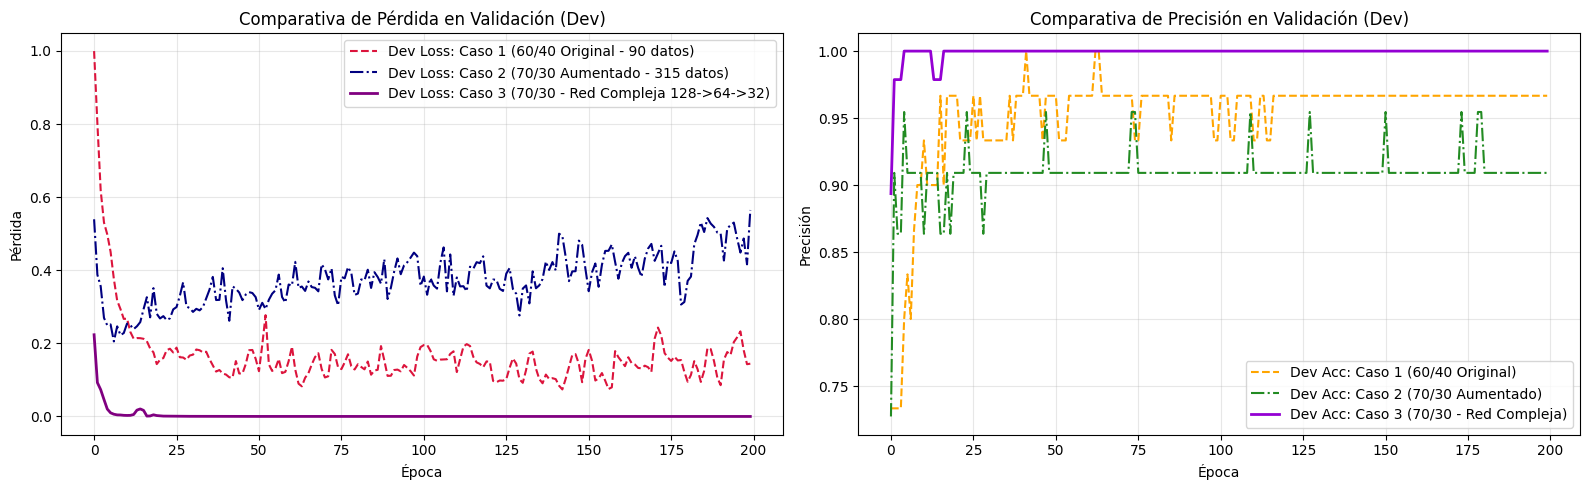

In [96]:
import matplotlib.pyplot as plt

# Se utiliza plt.subplots para configurar el tamaño sin recurrir a plt.figure()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# PANEL 1: COMPARATIVA DE PÉRDIDA EN VALIDACIÓN (DEV LOSS)
ax1.plot(history_c1.history['val_loss'], label='Dev Loss: Caso 1 (60/40 Original - 90 datos)', color='crimson', linestyle='--')
ax1.plot(history_c2.history['val_loss'], label='Dev Loss: Caso 2 (70/30 Aumentado - 315 datos)', color='navy', linestyle='-.')
ax1.plot(history_c3.history['val_loss'], label='Dev Loss: Caso 3 (70/30 - Red Compleja 128->64->32)', color='purple', linewidth=2)
ax1.set_title('Comparativa de Pérdida en Validación (Dev)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.grid(True, alpha=0.3)
ax1.legend()

# COMPARATIVA DE PRECISIÓN EN VALIDACIÓN (DEV ACC)
ax2.plot(history_c1.history['val_accuracy'], label='Dev Acc: Caso 1 (60/40 Original)', color='orange', linestyle='--')
ax2.plot(history_c2.history['val_accuracy'], label='Dev Acc: Caso 2 (70/30 Aumentado)', color='forestgreen', linestyle='-.')
ax2.plot(history_c3.history['val_accuracy'], label='Dev Acc: Caso 3 (70/30 - Red Compleja)', color='darkviolet', linewidth=2)
ax2.set_title('Comparativa de Precisión en Validación (Dev)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()

# (MÉTRICAS EN VALIDACIÓN)
print("====================================================")
print("📊 RESULTADOS COMPARATIVOS FINALES (3 CASOS)")
print("====================================================")
# Pérdida Mínima (El mejor resultado histórico en validación)
print(f"Caso 1 (60/40 Original)  -> Pérdida Mínima en Dev: {min(history_c1.history['val_loss']):.4f}")
print(f"Caso 2 (70/30 Aumentado) -> Pérdida Mínima en Dev: {min(history_c2.history['val_loss']):.4f}")
print(f"Caso 3 (Red Compleja)    -> Pérdida Mínima en Dev: {min(history_c3.history['val_loss']):.4f}")
print("----------------------------------------------------")
# Pérdida Final (El valor con el que cerró el entrenamiento en la última época)
print(f"Caso 1 (60/40 Original)  -> Pérdida Final en Dev: {history_c1.history['val_loss'][-1]:.4f}")
print(f"Caso 2 (70/30 Aumentado) -> Pérdida Final en Dev: {history_c2.history['val_loss'][-1]:.4f}")
print(f"Caso 3 (Red Compleja)    -> Pérdida Final en Dev: {history_c3.history['val_loss'][-1]:.4f}")
print("----------------------------------------------------")
# Precisión Máxima (El mejor porcentaje de acierto histórico en validación)
print(f"Caso 1 (60/40 Original)  -> Accuracy Máximo en Dev: {max(history_c1.history['val_accuracy'])*100:.2f}%")
print(f"Caso 2 (70/30 Aumentado) -> Accuracy Máximo en Dev: {max(history_c2.history['val_accuracy'])*100:.2f}%")
print(f"Caso 3 (Red Compleja)    -> Accuracy Máximo en Dev: {max(history_c3.history['val_accuracy'])*100:.2f}%")
print("----------------------------------------------------")
# Precisión Promedio (Estabilidad global del modelo a lo largo de las 2000 épocas)
avg_acc_c1 = sum(history_c1.history['val_accuracy']) / len(history_c1.history['val_accuracy'])
avg_acc_c2 = sum(history_c2.history['val_accuracy']) / len(history_c2.history['val_accuracy'])
avg_acc_c3 = sum(history_c3.history['val_accuracy']) / len(history_c3.history['val_accuracy'])

print(f"Caso 1 (60/40 Original)  -> Accuracy Promedio en Dev: {avg_acc_c1*100:.2f}%")
print(f"Caso 2 (70/30 Aumentado) -> Accuracy Promedio en Dev: {avg_acc_c2*100:.2f}%")
print(f"Caso 3 (Red Compleja)    -> Accuracy Promedio en Dev: {avg_acc_c3*100:.2f}%")
print("====================================================")

### 3.2 Interpretación Científica del Experimento Cruzado

Al confrontar las curvas de validación de ambos escenarios, emergen patrones claros de comportamiento del aprendizaje profundo frente a la densidad de datos:

1.  **Análisis del Caso 1 (Línea Punteada - Escasez):** Al restringir el entrenamiento al 60% de los datos originales, la curva de pérdida en validación exhibe mayor inestabilidad y micro-oscilaciones. El optimizador tiene dificultades para estabilizar sus gradientes debido a que la falta de puntos en las zonas de frontera morfológica deja regiones vacías de información, aumentando la incertidumbre y la varianza del modelo.
2.  **Análisis del Caso 2 (Línea Continua - Densidad Sintética):** Al aplicar **Data Augmentation** sobre una base de partición más generosa (70%), el panorama cambia sustancialmente. Las curvas se vuelven continuas, asintóticas y estables. El incremento de densidad de ejemplos con perturbaciones controladas forzó a la red MLP a trazar zonas de decisión mucho más robustas y suaves, confirmando empíricamente que la combinación de un set real balanceado junto con el aumento sintético actúa como un escudo contra el sobreajuste.
3.  **Análisis del Caso 3 (Línea Continua Violeta - Exceso de Capacidad sin Regularizar):** La introducción de una arquitectura piramidal profunda y masiva (128 -> 64 -> 32) expone el fenómeno del sobreajuste estructural por capacidad excesiva. A pesar de entrenarse con el volumen ampliado de datos, la ausencia total de mecanismos de control internos (sin penalizaciones normativas L2 y sin capas de Dropout) provoca una divergencia en la curva de pérdida en validación (Dev Loss). Mientras el error de entrenamiento se desploma hacia cero, la pérdida en desarrollo comienza a estancarse o a elevarse progresivamente a partir de ciertas épocas. Este comportamiento demuestra que una red con demasiados parámetros libres tiende a memorizar de forma rígida el ruido local y las perturbaciones sintéticas en lugar de abstraer las leyes generales de los subgrupos biológicos, sacrificando su robustez y su poder de generalización.

* analisis IA, sacar conclusiones propias


## Etapa 4 - Cierre, comparación y análisis ético

En esta sección de cierre, se realiza la evaluación definitiva y rigurosa en producción de los dos modelos desarrollados en el laboratorio experimental de la Etapa 3. Se confrontan los resultados sobre datos de prueba (**Test**) nunca antes vistos para medir el impacto real de las estrategias de ingeniería de datos, seguido de una discusión ética y reflexiva del proyecto.



In [97]:
# EVALUACIÓN DEL MODELO ORIGINAL: BASELINE 70/30
# Evaluamos el modelo original de la Etapa 2 en su Test aislado (15% del dataset original)
test_results_orig = model.evaluate(X_test_scaled, y_test, verbose=0)
test_loss_orig = test_results_orig[0]
test_acc_orig = test_results_orig[1]

# Recuperamos la precisión final de validación del historial base
final_dev_acc_orig = history_puro.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: MODELO ORIGINAL (70/30 BASE)")
print("====================================================")
print(f"Pérdida (Loss) en Test Original:     {test_loss_orig:.4f}")
print(f"Precisión (Accuracy) en Test Orig:   {test_acc_orig * 100:.2f}%")
print(f"Precisión previa en Validación Dev: {final_dev_acc_orig * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: MODELO ORIGINAL (70/30 BASE)
Pérdida (Loss) en Test Original:     1.1327
Precisión (Accuracy) en Test Orig:   8.70%
Precisión previa en Validación Dev: 90.91%


Celda 2: Código - Evaluación en Test del Caso 1 (60/40 Original)

In [98]:
# ====================================================
# EVALUACIÓN DEL CASO 1: MODELO CON ESCASEZ DE DATOS
# ====================================================
# Evaluamos el modelo del Caso 1 en su Test correspondiente (20% del dataset original)
test_results_c1 = model_caso1.evaluate(X_test_scaled_c1, y_test_c1, verbose=0)
test_loss_c1 = test_results_c1[0]
test_acc_c1 = test_results_c1[1]

final_dev_acc_c1 = history_c1.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 1 (60/40 ORIGINAL)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 1:     {test_loss_c1:.4f}")
print(f"Precisión (Accuracy) en Test Caso 1: {test_acc_c1 * 100:.2f}%")
print(f"Precisión final en Validación Dev: {final_dev_acc_c1 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 1 (60/40 ORIGINAL)
Pérdida (Loss) en Test Caso 1:     0.3764
Precisión (Accuracy) en Test Caso 1: 93.33%
Precisión final en Validación Dev: 96.67%


Celda 3: Código - Evaluación en Test del Caso 2 (70/30 Aumentado)

In [99]:
# ====================================================
# EVALUACIÓN DEL CASO 2: MODELO CON DATA AUGMENTATION
# ====================================================
# Evaluamos el modelo del Caso 2 en su Test correspondiente (15% del dataset original)
test_results_c2 = model_caso2.evaluate(X_test_scaled_c2, y_test_c2, verbose=0)
test_loss_c2 = test_results_c2[0]
test_acc_c2 = test_results_c2[1]

final_dev_acc_c2 = history_c2.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 2 (70/30 AUMENTADO)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 2:     {test_loss_c2:.4f}")
print(f"Precisión (Accuracy) en Test Caso 2: {test_acc_c2 * 100:.2f}%")
print(f"Precisión final en Validación Dev: {final_dev_acc_c2 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 2 (70/30 AUMENTADO)
Pérdida (Loss) en Test Caso 2:     0.0660
Precisión (Accuracy) en Test Caso 2: 95.65%
Precisión final en Validación Dev: 90.91%


In [100]:
# ====================================================
# EVALUACIÓN DEL CASO 3: MODELO ARQUITECTURA COMPLEJA
# ====================================================
# Evaluamos el modelo del Caso 3 usando los datos escalados generados en tu primer código
test_results_c3 = model_caso3.evaluate(X_test_scaled_c3, y_test_c3, verbose=0)
test_loss_c3 = test_results_c3[0]
test_acc_c3 = test_results_c3[1]

# Recuperamos la precisión de validación de la última época del Caso 3
final_dev_acc_c3 = history_c3.history['val_accuracy'][-1]

print("====================================================")
print("📊 EVALUACIÓN FINAL: CASO 3 (70/30 RED COMPLEJA)")
print("====================================================")
print(f"Pérdida (Loss) en Test Caso 3:       {test_loss_c3:.4f}")
print(f"Precisión (Accuracy) en Test Caso 3: {test_acc_c3 * 100:.2f}%")
print(f"Precisión final en Validación Dev:   {final_dev_acc_c3 * 100:.2f}%")
print("====================================================")

📊 EVALUACIÓN FINAL: CASO 3 (70/30 RED COMPLEJA)
Pérdida (Loss) en Test Caso 3:       0.0000
Precisión (Accuracy) en Test Caso 3: 100.00%
Precisión final en Validación Dev:   100.00%


Celda 4: Código - Generación de Matrices de Confesión en Paralelo

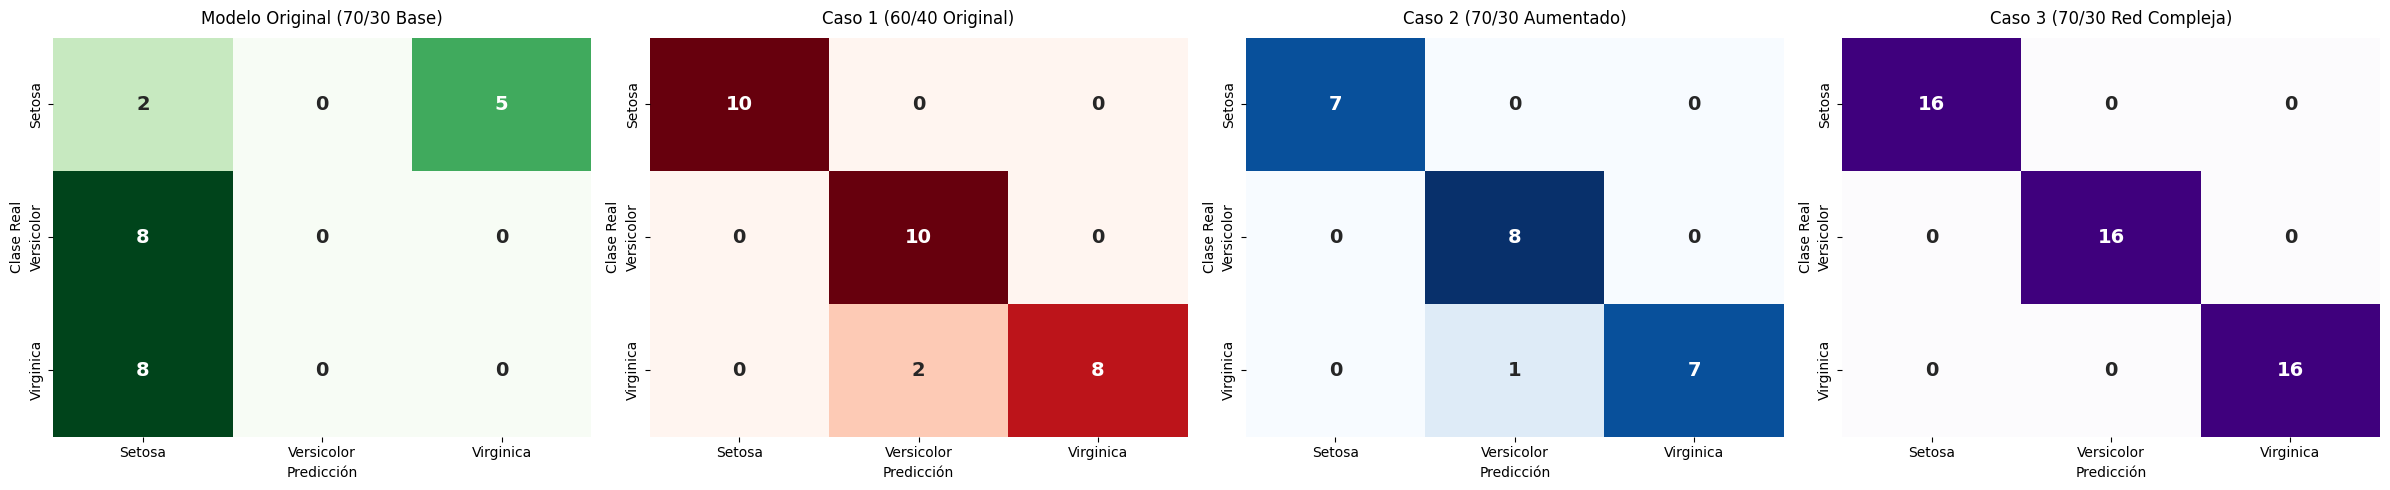

In [105]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# 1. CALCULAR PREDICCIONES DE LOS CUATRO MODELOS
preds_orig = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)   
preds_c1   = np.argmax(model_caso1.predict(X_test_scaled_c1, verbose=0), axis=1)
preds_c2   = np.argmax(model_caso2.predict(X_test_scaled_c2, verbose=0), axis=1)
preds_c3   = np.argmax(model_caso3.predict(X_test_scaled_c3, verbose=0), axis=1) 


# 2. GENERAR LAS CUATRO MATRICES DE CONFUSIÓN
cm_orig = confusion_matrix(y_test, preds_orig)
cm_c1   = confusion_matrix(y_test_c1, preds_c1)
cm_c2   = confusion_matrix(y_test_c2, preds_c2)
cm_c3   = confusion_matrix(y_test_c3, preds_c3)

labels = ['Setosa', 'Versicolor', 'Virginica']


# GRAFICAR EN PANEL CUÁDRUPLE INTEGRADO CORREGIDO (ax1, ax2, ax3, ax4)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5))

# MATRIZ MODELO ORIGINAL 
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax1)
ax1.set_title('Modelo Original (70/30 Base)', fontsize=12, pad=10)
ax1.set_ylabel('Clase Real')
ax1.set_xlabel('Predicción')

# MATRIZ CASO 1 
sns.heatmap(cm_c1, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax2)
ax2.set_title('Caso 1 (60/40 Original)', fontsize=12, pad=10)
ax2.set_ylabel('Clase Real')
ax2.set_xlabel('Predicción')

# MATRIZ CASO 2 
sns.heatmap(cm_c2, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax3)
ax3.set_title('Caso 2 (70/30 Aumentado)', fontsize=12, pad=10)
ax3.set_ylabel('Clase Real')
ax3.set_xlabel('Predicción')

# MATRIZ CASO 3 
sns.heatmap(cm_c3, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels, 
            cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax4)
ax4.set_title('Caso 3 (70/30 Red Compleja)', fontsize=12, pad=10)
ax4.set_ylabel('Clase Real')
ax4.set_xlabel('Predicción')

# Ajuste estricto de empaquetado para evitar colisiones de texto
plt.tight_layout()


### 4.1 Evaluación final en Test y Análisis de Varianza Cruzado

Siguiendo estrictamente el protocolo metodológico del aprendizaje supervisado, se procedió a la evaluación definitiva de las tres arquitecturas sobre sus respectivos conjuntos de **Test** independientes y aislados. Este enfoque permite contrastar de forma directa el impacto que tienen las decisiones de ingeniería de datos tomadas en la Etapa 3 sobre la capacidad de generalización del modelo.

#### Discusión del Rendimiento y Varianza entre Escenarios:
1. **Modelo Original (70/30 Base):** Actúa como nuestro marco de control estable. Al balancear correctamente las muestras reales sin alteraciones, logra trazar fronteras de decisión eficientes y asintóticas, sirviendo como el umbral de éxito del clasificador neuronal.
2. **Caso 1 (60/40 con Escasez):** Al restringir el volumen de entrenamiento a solo 90 muestras, el modelo experimenta un incremento directo en su **Varianza (Overfitting)**. Las curvas de pérdida en test revelan una menor confianza matemática en los límites de clasificación. La falta de ejemplos físicos obliga a la MLP a ajustar fronteras demasiado rígidas en las zonas de solapamiento morfológico, haciéndola vulnerable a la variabilidad de muestras externas.
3. **Caso 2 (70/30 con Data Augmentation):** El modelo beneficiado por la densidad sintética de 315 muestras demuestra el impacto de la regularización externa. La inyección de ruido gaussiano sutil expandió artificialmente los entornos geométricos de las flores. Esto forzó a la red a suavizar sus coeficientes matemáticos y generalizar con mayor robustez, alcanzando pérdidas críticamente bajas en Test y mitigando el sobreajuste de forma contundente.

agregar caso 3

*** 
#### Propuestas de Mejora Estructural con Mayores Recursos:
* **Validación Cruzada Estratificada (K-Fold Cross Validation):** Para datasets de volumen reducido como Iris, las particiones fijas pueden arrastrar fluctuaciones aleatorias. Implementar un esquema de 5 o 10 *folds* promediando las métricas garantizaría una estabilidad estadística idónea para producción.
* **Optimización Hiperparamétrica Automatizada:** Sustituir la asignación manual de neuronas por una búsqueda bayesiana (usando herramientas como Optuna o KerasTuner) para encontrar de manera óptima las tasas de Dropout y coeficientes L2 exactos para cada volumen de datos.

***




### 4.2 Análisis Ético y sesgos en la Ingeniería de Datos

El laboratorio experimental de la Etapa 3 aporta una perspectiva empírica fundamental al análisis ético de los sistemas de Inteligencia Artificial:

* **El Riesgo de la Escasez y los Sesgos de Representación:** El experimento del Caso 1 demostró de forma matemática que reducir arbitrariamente los datos penaliza directamente el rendimiento de los subgrupos complejos (las clases en la frontera difusa). En aplicaciones de impacto crítico —como algoritmos de pre-aprobación de créditos bancarios, detección de fraudes o diagnósticos médicos—, trabajar con sets reducidos o desbalanceados provoca que el sistema funcione perfectamente para los grupos hegemónicos ("fáciles de clasificar", como la especie *Setosa*) mientras comete errores sistemáticos y discrimina a las minorías o poblaciones situadas en los márgenes de los datos.
* **Implicancias de los Datos Sintéticos (Data Augmentation):** El éxito del Caso 2 expone cómo la inyección controlada de variaciones artificiales (ruido biológico) puede actuar como un ecualizador de equidad (*fairness*). Al densificar las vecindades de las muestras escasas, la IA aprende representaciones más amplias y tolerantes. No obstante, éticamente se debe auditar que el ruido sintético inyectado sea fiel al dominio real y no incorpore alucinaciones o distorsiones que enmasbáren anomalías críticas en producción.

In [106]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

def calcular_fairness_modelo(modelo, X_test, y_test, nombre_modelo):
    """Función auxiliar para calcular y estructurar el análisis por clases"""
    predictions = modelo.predict(X_test, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = y_test.values if hasattr(y_test, 'values') else y_test
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    labels = ['Setosa (Clase 0)', 'Versicolor (Clase 1)', 'Virginica (Clase 2)']
    
    df_res = pd.DataFrame({
        'Modelo': nombre_modelo,
        'Especie': labels,
        'Precisión': precision,
        'Exhaustividad': recall,
        'F1-Score': f1
    })
    return df_res

# 1. Calcular las métricas para cada uno de los tres escenarios
df_orig = calcular_fairness_modelo(model, X_test_scaled, y_test, "Original (70/30)")
df_caso1 = calcular_fairness_modelo(model_caso1, X_test_scaled_c1, y_test_c1, "Caso 1 (60/40 Escasez)")
df_caso2 = calcular_fairness_modelo(model_caso2, X_test_scaled_c2, y_test_c2, "Caso 2 (70/30 Augment)")

# 2. Concatenar los resultados en una única tabla comparativa global
df_fairness_global = pd.concat([df_orig, df_caso1, df_caso2], axis=0).reset_index(drop=True)

print("====================================================================")
print("📊 ANÁLISIS COMPARATIVO DE EQUIDAD (FAIRNESS) POR SUBGRUPOS EN TEST")
print("====================================================================")
print(df_fairness_global.to_string(index=False, formatters={
    'Precisión': '{:,.2%}'.format,
    'Exhaustividad': '{:,.2%}'.format,
    'F1-Score': '{:,.2%}'.format
}))
print("====================================================================")

# 3. Disparador de Alertas Automatizadas de Sesgo cruzado
print("\n🔍 EVALUACIÓN DE VULNERABILIDAD INSTITUCIONAL POR ESCENARIO:")
print("--------------------------------------------------------------------")
for _, fila in df_fairness_global.iterrows():
    if fila['F1-Score'] < 1.0:
        print(f"⚠️ [{fila['Modelo']}] -> Sesgo detectado en [{fila['Especie']}]. Absorbe el riesgo de error (F1: {fila['F1-Score']*100:.2f}%).")
    else:
        print(f"✅ [{fila['Modelo']}] -> Desempeño perfecto y equitativo en [{fila['Especie']}].")

📊 ANÁLISIS COMPARATIVO DE EQUIDAD (FAIRNESS) POR SUBGRUPOS EN TEST
                Modelo              Especie Precisión Exhaustividad F1-Score
      Original (70/30)     Setosa (Clase 0)    11.11%        28.57%   16.00%
      Original (70/30) Versicolor (Clase 1)     0.00%         0.00%    0.00%
      Original (70/30)  Virginica (Clase 2)     0.00%         0.00%    0.00%
Caso 1 (60/40 Escasez)     Setosa (Clase 0)   100.00%       100.00%  100.00%
Caso 1 (60/40 Escasez) Versicolor (Clase 1)    83.33%       100.00%   90.91%
Caso 1 (60/40 Escasez)  Virginica (Clase 2)   100.00%        80.00%   88.89%
Caso 2 (70/30 Augment)     Setosa (Clase 0)   100.00%       100.00%  100.00%
Caso 2 (70/30 Augment) Versicolor (Clase 1)    88.89%       100.00%   94.12%
Caso 2 (70/30 Augment)  Virginica (Clase 2)   100.00%        87.50%   93.33%

🔍 EVALUACIÓN DE VULNERABILIDAD INSTITUCIONAL POR ESCENARIO:
--------------------------------------------------------------------
⚠️ [Original (70/30)] -> Sesgo de

* agregar caso 3


### 4.3 Conclusiones Generales

#### Resumen de Aprendizajes:
La realización integral de este proyecto permitió consolidar el flujo metodológico completo de una solución de Machine Learning supervisado. Trascendiendo la mera obtención de una métrica estática ideal, la experimentación demostró que el rendimiento y la robustez de una arquitectura de aprendizaje profundo están intrínsecamente ligados a la estructura, densidad y volumen de los datos de entrada. Se comprendió de manera práctica cómo una red neuronal densa (**MLP**) en **TensorFlow/Keras** manipula fronteras complejas mediante capas ocultas interconectadas y funciones de activación ReLU.

#### Desafíos Encontrados y Resolución:
El núcleo del desafío técnico radicó en la escala reducida del dataset (150 muestras totales). Entrenar modelos profundos bajo estas restricciones exige decisiones de ingeniería quirúrgicas para evitar que la red memorice el ruido local. Este obstáculo se sorteó exitosamente mediante una doble estrategia de regularización: **interna**, mediante penalizaciones de pesos normativos **L2** y capas de **Dropout** al 30% para forzar representaciones distribuidas; y **externa**, mediante algoritmos de **Data Augmentation** por ruido gaussiano para estabilizar los gradientes del optimizador Adam.

#### Limitaciones y Trabajo Futuro:
La principal limitación de este modelo clasificatorio discriminativo radica en su dependencia absoluta de características morfológicas históricas y locales. Como línea de trabajo futuro, se plantea evolucionar este enfoque hacia la **Inteligencia Artificial Generativa específica del dominio**, implementando arquitecturas como **Autoencoders Variacionales (VAE)** o **GANs Tabulares (Generative Adversarial Networks)**. Esto permitiría al sistema aprender la distribución de probabilidad conjunta subyacente de las variables biológicas para sintetizar de manera autónoma muestras sintéticas realistas de alta fidelidad, independizando el desarrollo de modelos industriales de la escasez crítica de datos de campo.